In [1]:
import uproot
import awkward as ak
import dask_awkward as dak
from dask.diagnostics import ProgressBar
import numpy as np
import pandas as pd

import zfit
from hepstats.splot import compute_sweights

import matplotlib.pyplot as plt
import mplhep as hep
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

import joblib

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/__init__.py:93: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
tree_path = "Events"
data_files = {f: tree_path for f in [
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022C.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022D.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022E.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022F.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022G.root"
]}

mc_files = {f: tree_path for f in [
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_mc_jpsi_2022.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_mc_jpsi_2022EE.root"
]}

In [3]:
def get_b0_truth_mask(df):
    PDG_B0        =  511
    PDG_KSTAR     =  313
    PDG_KAON_plus =  321
    PDG_PION_neg  = -211
    PDG_PHOTON    =  22
    PDG_JPSI      =  443
    PDG_MUON_plus = -13
    PDG_MUON_neg  =  13

    mu1_idx  = df["BPH_1Muon_genPartIdx"]
    mu2_idx  = df["BPH_2Muon_genPartIdx"]
    trk1_idx = df["Trk1_genPartIdx"]
    trk2_idx = df["Trk2_genPartIdx"]

    # Verificação de Identidade (PDG ID)
    mu1_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mu2_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu2_idx, mu2_idx >= 0)]
    trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(trk1_idx, trk1_idx >= 0)]
    trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(trk2_idx, trk2_idx >= 0)]

    flavor_match = (trk1_pdg == PDG_KAON_plus) & (trk2_pdg == PDG_PION_neg) & \
                   (mu1_pdg == PDG_MUON_plus) & (mu2_pdg == PDG_MUON_neg)

    # Linhagem do Hadron (K, Pi -> K* -> B0)
    mom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk1_idx, trk1_idx >= 0)]
    mom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk2_idx, trk2_idx >= 0)]
    
    mom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    mom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    # K e Pi devem vir do mesmo objeto K*0 
    match_kstar = (mom_trk1_idx == mom_trk2_idx) & (mom_trk1_idx >= 0) & \
                  (mom_trk1_pdg == PDG_KSTAR) & (mom_trk2_pdg == PDG_KSTAR)
    
    # O K*0 deve vir de um B0 (Verificando para ambos os traços)
    gmom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    gmom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    gmom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk1_idx, gmom_trk1_idx >= 0)]
    gmom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk2_idx, gmom_trk2_idx >= 0)]
    
    match_kstar_to_b0 = (gmom_trk1_idx == gmom_trk2_idx) & (gmom_trk1_idx >= 0) & \
                        (gmom_trk1_pdg == PDG_B0) & (gmom_trk2_pdg == PDG_B0)

    mom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu2_idx, mu2_idx >= 0)]
    mom_mu1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    mom_mu2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]
    
    gmom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    gmom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]
    gmom_mu1_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_mu1_idx, gmom_mu1_idx >= 0)]
    gmom_mu2_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_mu2_idx, gmom_mu2_idx >= 0)]  

    ggmom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(gmom_mu1_idx, gmom_mu1_idx >= 0)]
    ggmom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(gmom_mu2_idx, gmom_mu2_idx >= 0)]
    ggmom_mu1_pdg = df["BPHGenPart_pdgId"][dak.mask(ggmom_mu1_idx, ggmom_mu1_idx >= 0)]
    ggmom_mu2_pdg = df["BPHGenPart_pdgId"][dak.mask(ggmom_mu2_idx, ggmom_mu2_idx >= 0)]

    mu1_match = (mom_mu1_idx == gmom_trk1_idx) | \
            ((mom_mu1_pdg == PDG_PHOTON) & (gmom_mu2_pdg == PDG_JPSI) & (ggmom_mu1_idx == gmom_trk1_idx))
    mu2_match = (mom_mu2_idx == gmom_trk1_idx) | \
            ((mom_mu2_pdg == PDG_PHOTON) & (gmom_mu2_pdg == PDG_JPSI) & (ggmom_mu2_idx == gmom_trk1_idx))

    truth_match_final = flavor_match & match_kstar & match_kstar_to_b0 & mu1_match & mu2_match
    
    return ak.fill_none(truth_match_final, False)

In [4]:
def add_derived_columns(df):
    df["BToTrkTrkMuMu_l_xy_sig"] = df['BToTrkTrkMuMu_l_xy'] / df['BToTrkTrkMuMu_l_xy_unc']
    df["BToTrkTrkMuMu_dca_sig"]  = df['BToTrkTrkMuMu_dca'] / df['BToTrkTrkMuMu_dcaErr']
    df["BToTrkTrkMuMu_trk1_dca_sig"] = df['BToTrkTrkMuMu_trk1_dca'] / df['BToTrkTrkMuMu_trk1_dcaErr']
    df["BToTrkTrkMuMu_trk2_dca_sig"] = df['BToTrkTrkMuMu_trk2_dca'] / df['BToTrkTrkMuMu_trk2_dcaErr']
    return df

In [5]:
def apply_selection(df, mode="mc"):

    kstar_pdg = 0.892
    mask_kpi_window = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - kstar_pdg) <= 0.150
    mask_pik_window = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - kstar_pdg) <= 0.150
    is_kpi_closer = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - kstar_pdg) < \
                    abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - kstar_pdg)
    
    mask = (
        # Filtro de massa de dimuons (regiões de sinal, excluindo J/psi e Psi2S)
        (((df['MuMu_mass'] > 2.9) & (df['MuMu_mass'] < 3.3)) &
        
        # Pelo menos uma das combinações deve estar na janela de 3 sigma
        (mask_kpi_window | mask_pik_window) & 
        
        # Aplicamos a lógica de decisão de sabor (escolhemos a hipótese Kpi se ela for a melhor)
        (is_kpi_closer) &
        
        # Trigger e cortes cinemáticos dos múons
        (df['HLT_DoubleMu4_3_LowMass'] == 1) & 
        (df['BPH_1Muon_pt'] > 2.0) & (df['BPH_2Muon_pt'] > 2.0) & 
        (abs(df['BPH_1Muon_eta']) < 2.4) & (abs(df['BPH_2Muon_eta']) < 2.4) &
        (df['BToTrkTrkMuMu_fit_trk1_pt'] > 1.2) &
        (df['BToTrkTrkMuMu_fit_trk2_pt'] > 1.2) &

         ((df["BToTrkTrkMuMu_fit_mass_Kpi"] > 5.0) & (df["BToTrkTrkMuMu_fit_mass_Kpi"] < 5.6))
    ))
    if mode == "mc":
        mask = mask & get_b0_truth_mask(df) # No MC junta a mask de thruth Matching !!!
    else:
        mask = mask
    
    cols_to_keep = [
        "BToTrkTrkMuMu_fit_l1_pt", "BToTrkTrkMuMu_fit_l2_pt",
        "BToTrkTrkMuMu_fit_trk1_pt", "BToTrkTrkMuMu_fit_trk2_pt",
        "BToTrkTrkMuMu_fit_eta", "BToTrkTrkMuMu_fit_cos2D",
        "BToTrkTrkMuMu_trk1_dca_sig", "BToTrkTrkMuMu_trk2_dca_sig", "BToTrkTrkMuMu_fit_mass_Kpi"
    ]
    return df[cols_to_keep][mask]

In [6]:
def build_dataframe(file_dict, label="Dataset", mode="mc"):
    print(f"\nProcessando {label}...")
    
    df = uproot.dask(file_dict)
    df = add_derived_columns(df)
    df = apply_selection(df, mode=mode)
    
    with ProgressBar():
        awkward_array = df.compute()
        df_pandas = ak.to_dataframe(awkward_array).reset_index(drop=True)
    
    print(f"{label} finalizado. Linhas: {len(df_pandas)}")
    return df_pandas

In [7]:
df_data = build_dataframe(data_files, "Data (Sidebands)", mode="data")
df_mc   = build_dataframe(mc_files, "MC Signal (Truth Matched)", mode="mc")


Processando Data (Sidebands)...
[########################################] | 100% Completed | 207.33 ms
[                                        ] | 0% Completed | 11.93 sms

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


[########################################] | 100% Completed | 51.26 s
Data (Sidebands) finalizado. Linhas: 1834824

Processando MC Signal (Truth Matched)...
[########################################] | 100% Completed | 209.82 ms
[                                        ] | 0% Completed | 3.90 s ms

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


[########################################] | 100% Completed | 6.89 s
MC Signal (Truth Matched) finalizado. Linhas: 442368


In [8]:
df_data.keys()

Index(['BToTrkTrkMuMu_fit_l1_pt', 'BToTrkTrkMuMu_fit_l2_pt',
       'BToTrkTrkMuMu_fit_trk1_pt', 'BToTrkTrkMuMu_fit_trk2_pt',
       'BToTrkTrkMuMu_fit_eta', 'BToTrkTrkMuMu_fit_cos2D',
       'BToTrkTrkMuMu_trk1_dca_sig', 'BToTrkTrkMuMu_trk2_dca_sig',
       'BToTrkTrkMuMu_fit_mass_Kpi'],
      dtype='object')

In [9]:
obs = zfit.Space("BToTrkTrkMuMu_fit_mass_Kpi", limits=(5.0, 5.6))
data_zfit = zfit.Data.from_pandas(df_data["BToTrkTrkMuMu_fit_mass_Kpi"], obs=obs)

In [10]:
mu    = zfit.Parameter("mu", 5.28, 5.15, 5.40)
sigma = zfit.Parameter("sigma", 0.025, 0.005, 0.100)
alphal = zfit.Parameter("alphal", 1.5, 0.1, 5.0)
nl     = zfit.Parameter("nl", 5.0, 0.1, 100.0)
alphar = zfit.Parameter("alphar", 1.5, 0.1, 5.0)
nr     = zfit.Parameter("nr", 5.0, 0.1, 30.0)

In [11]:
tau = zfit.Parameter("tau", -2.0, -10.0, 0.0)

In [12]:
total_ev = len(df_data)
n_sig = zfit.Parameter("n_sig", total_ev * 0.1, 0, total_ev)
n_bkg = zfit.Parameter("n_bkg", total_ev * 0.9, 0, total_ev)

In [13]:
signal_pdf = zfit.pdf.DoubleCB(mu=mu, sigma=sigma, alphal=alphal, nl=nl, alphar=alphar, nr=nr, obs=obs)
bkg_pdf    = zfit.pdf.Exponential(lambda_=tau, obs=obs)

signal_ext = signal_pdf.create_extended(n_sig)
bkg_ext    = bkg_pdf.create_extended(n_bkg)
model = zfit.pdf.SumPDF([signal_ext, bkg_ext])

In [14]:
nll = zfit.loss.ExtendedUnbinnedNLL(model, data_zfit)
minimizer = zfit.minimize.Minuit(tol=1e-3)
result = minimizer.minimize(nll)

In [15]:
print(result)

FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_1, Composed_autoparam_2]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi',) shape=(1834824, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  False  │    True     │       True       │ 0.00022 │      -1398552.52 | -156899.4 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name      value  (rounded)    at limit
------  ------------------  ----------
n_sig               756912       False
n_bkg          1.07791e+06       False
mu                 5.27386       False
sigma            0.0320086       False
alphal            0.868595       False
nl               

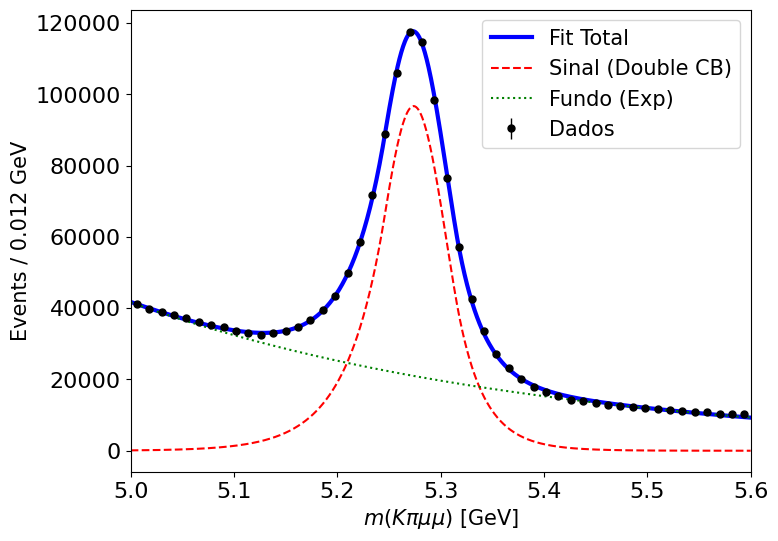

In [16]:
plt.figure(figsize=(8, 6))
counts, edges = np.histogram(df_data["BToTrkTrkMuMu_fit_mass_Kpi"], bins=50, range=(5.0, 5.6))
hep.histplot(counts, bins=edges, yerr=True, histtype='errorbar', color='black', label='Dados')

x_plot = np.linspace(5.0, 5.6, 1000)
bw = 0.012 
plt.plot(x_plot, model.ext_pdf(x_plot).numpy() * bw, color='blue', lw=3, label='Fit Total')
plt.plot(x_plot, signal_ext.ext_pdf(x_plot).numpy() * bw, color='red', ls='--', label='Sinal (Double CB)')
plt.plot(x_plot, bkg_ext.ext_pdf(x_plot).numpy() * bw, color='green', ls=':', label='Fundo (Exp)')

plt.xlabel(r"$m(K \pi \mu \mu)$ [GeV]", fontsize = 15)
plt.ylabel(f"Events / {bw:.3f} GeV", fontsize = 15)
plt.xlim(5.0, 5.6)
plt.legend(fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.show()

In [17]:
weights = compute_sweights(model, data_zfit)
s_weights_sig = weights[n_sig]
df_data["sweight_sig"] = s_weights_sig

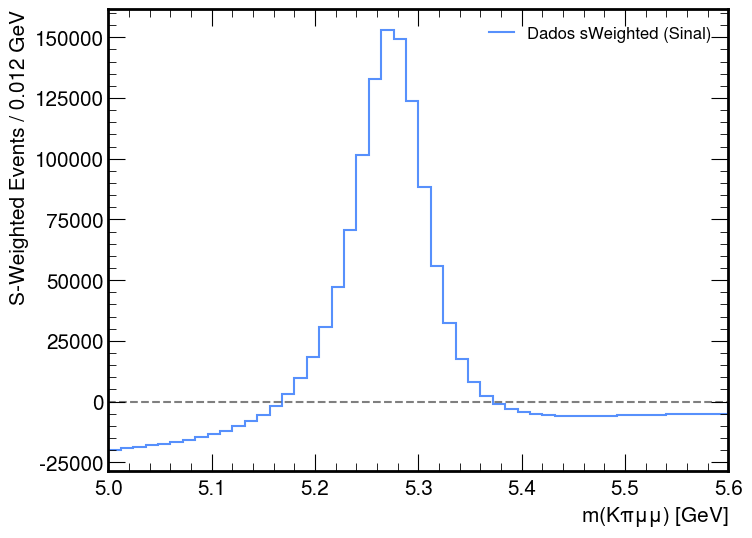

In [18]:
plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(8, 6))

counts, edges = np.histogram(df_data["BToTrkTrkMuMu_fit_mass_Kpi"], bins=50, range=(5.0, 5.6), weights=df_data["sweight_sig"])
hep.histplot(counts, bins=edges, label='Dados sWeighted (Sinal)', ax=ax)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel(r"$m(K \pi \mu \mu)$ [GeV]", fontsize=15)
ax.set_ylabel(f"S-Weighted Events / {bw:.3f} GeV", fontsize=15)
ax.legend(fontsize=12, frameon=False)

plt.xlim(5.0, 5.6)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

## BDT REWEIGHTER

In [19]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import mplhep as hep

plt.style.use(hep.style.CMS)

In [20]:
FEATURES = [
    "BToTrkTrkMuMu_fit_l1_pt",
    "BToTrkTrkMuMu_fit_l2_pt",
    "BToTrkTrkMuMu_fit_trk1_pt",
    "BToTrkTrkMuMu_fit_trk2_pt",
    "BToTrkTrkMuMu_fit_eta",
    "BToTrkTrkMuMu_fit_cos2D",
    "BToTrkTrkMuMu_trk1_dca_sig",
    "BToTrkTrkMuMu_trk2_dca_sig",
]

FEATURE_LABELS = {
    "BToTrkTrkMuMu_fit_l1_pt":    r"$p_T(\mu_1)$ [GeV]",
    "BToTrkTrkMuMu_fit_l2_pt":    r"$p_T(\mu_2)$ [GeV]",
    "BToTrkTrkMuMu_fit_trk1_pt":  r"$p_T(trk_1)$ [GeV]",
    "BToTrkTrkMuMu_fit_trk2_pt":  r"$p_T(trk_2)$ [GeV]",
    "BToTrkTrkMuMu_fit_eta":      r"$\eta(B^0)$",
    "BToTrkTrkMuMu_fit_cos2D":    r"$\cos\alpha_{2D}$",
    "BToTrkTrkMuMu_trk1_dca_sig": r"DCA sig $(trk_1)$",
    "BToTrkTrkMuMu_trk2_dca_sig": r"DCA sig $(trk_2)$",
}

def clean_df(df, features):
    df = df.copy()
    df[features] = df[features].replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=features).reset_index(drop=True)
    return df

df_data_clean = clean_df(df_data, FEATURES)
df_mc_clean   = clean_df(df_mc,   FEATURES)

print(f"Data após limpeza: {len(df_data_clean)}")
print(f"MC após limpeza:   {len(df_mc_clean)}")

Data após limpeza: 1834824
MC após limpeza:   442368


In [21]:
TRK_PT_MIN = 1.2

df_data_clean = df_data_clean[
    (df_data_clean["BToTrkTrkMuMu_fit_trk1_pt"] > TRK_PT_MIN) &
    (df_data_clean["BToTrkTrkMuMu_fit_trk2_pt"] > TRK_PT_MIN)
].reset_index(drop=True)

df_mc_clean = df_mc_clean[
    (df_mc_clean["BToTrkTrkMuMu_fit_trk1_pt"] > TRK_PT_MIN) &
    (df_mc_clean["BToTrkTrkMuMu_fit_trk2_pt"] > TRK_PT_MIN)
].reset_index(drop=True)

print(f"Data após corte pT > {TRK_PT_MIN} GeV: {len(df_data_clean)}")
print(f"MC após corte pT > {TRK_PT_MIN} GeV:   {len(df_mc_clean)}")

Data após corte pT > 1.2 GeV: 1834824
MC após corte pT > 1.2 GeV:   442368


In [22]:
def add_parity(df, random_state=42):
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    df["parity"] = df.index % 2
    return df

df_data_clean = add_parity(df_data_clean)
df_mc_clean   = add_parity(df_mc_clean)

df_data_even = df_data_clean[df_data_clean["parity"] == 0].copy()
df_mc_even   = df_mc_clean[df_mc_clean["parity"] == 0].copy()
df_data_odd  = df_data_clean[df_data_clean["parity"] == 1].copy()
df_mc_odd    = df_mc_clean[df_mc_clean["parity"] == 1].copy()

print(f"Even → Data: {len(df_data_even)}  MC: {len(df_mc_even)}  (treinamento)")
print(f"Odd  → Data: {len(df_data_odd)}   MC: {len(df_mc_odd)}   (closure)")

Even → Data: 917412  MC: 221184  (treinamento)
Odd  → Data: 917412   MC: 221184   (closure)


In [23]:
data_train = df_data_even[FEATURES + ["sweight_sig"]].copy()
mc_train   = df_mc_even[FEATURES].copy()

data_train["label"]  = 1
data_train["weight"] = data_train["sweight_sig"]
mc_train["label"]    = 0
mc_train["weight"]   = 1.0

# Remove sWeights negativos
data_train = data_train[data_train["weight"] > 0]

# Normaliza pesos para balancear as classes
sum_w_data = data_train["weight"].sum()
sum_w_mc   = mc_train["weight"].sum()
data_train["weight"] = data_train["weight"] * (sum_w_mc / sum_w_data)

print(f"Soma pesos data (após norm): {data_train['weight'].sum():.1f}")
print(f"Soma pesos MC:               {mc_train['weight'].sum():.1f}")

df_train = pd.concat([data_train, mc_train], ignore_index=True)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

X = df_train[FEATURES]
y = df_train["label"]
w = df_train["weight"]

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.1, random_state=42, stratify=y
)

print(f"\nTreino: {len(X_train)}  |  Teste: {len(X_test)}")
print(f"  label=1 (data): {(y_train==1).sum()}  label=0 (MC): {(y_train==0).sum()}")

Soma pesos data (após norm): 221184.0
Soma pesos MC:               221184.0

Treino: 689765  |  Teste: 76641
  label=1 (data): 490700  label=0 (MC): 199065


In [24]:
clf = xgb.XGBClassifier(
    objective             = "multi:softprob",
    num_class             = 2,
    eval_metric           = "mlogloss",
    learning_rate         = 0.1,
    max_depth             = 7,
    n_estimators          = 500,
    early_stopping_rounds = 10,
    random_state          = 42,
    n_jobs                = -1,
)

clf.fit(
    X_train, y_train,
    sample_weight          = w_train,
    eval_set               = [(X_train, y_train), (X_test, y_test)],
    sample_weight_eval_set = [w_train, w_test],
    verbose                = 50,
)

print(f"\nMelhor iteração: {clf.best_iteration}")

[0]	validation_0-mlogloss:0.68838	validation_1-mlogloss:0.68843
[50]	validation_0-mlogloss:0.65204	validation_1-mlogloss:0.65727
[100]	validation_0-mlogloss:0.64606	validation_1-mlogloss:0.65585
[133]	validation_0-mlogloss:0.64250	validation_1-mlogloss:0.65526

Melhor iteração: 124


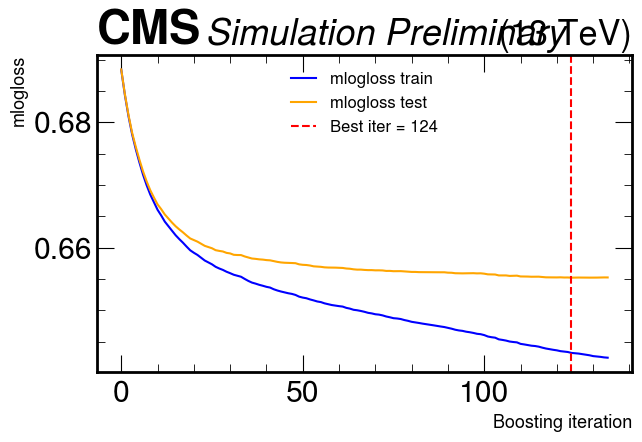

In [25]:
results  = clf.evals_result()
train_ll = results["validation_0"]["mlogloss"]
test_ll  = results["validation_1"]["mlogloss"]
best_it  = clf.best_iteration

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_ll, label="mlogloss train", color="blue")
ax.plot(test_ll,  label="mlogloss test",  color="orange")
ax.axvline(best_it, color="red", ls="--", lw=1.5, label=f"Best iter = {best_it}")
ax.set_xlabel("Boosting iteration", fontsize=13)
ax.set_ylabel("mlogloss", fontsize=13)
ax.legend(fontsize=12, frameon=False)
hep.cms.label("Preliminary", ax=ax)
plt.tight_layout()
plt.show()

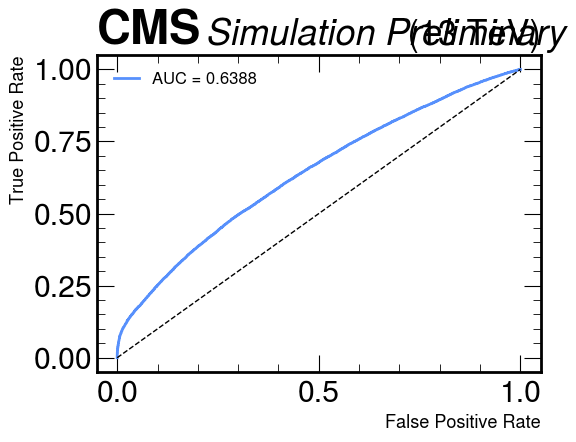

In [26]:
proba_test  = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_test, sample_weight=w_test)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.legend(fontsize=12, frameon=False)
hep.cms.label("Preliminary", ax=ax)
plt.tight_layout()
plt.show()

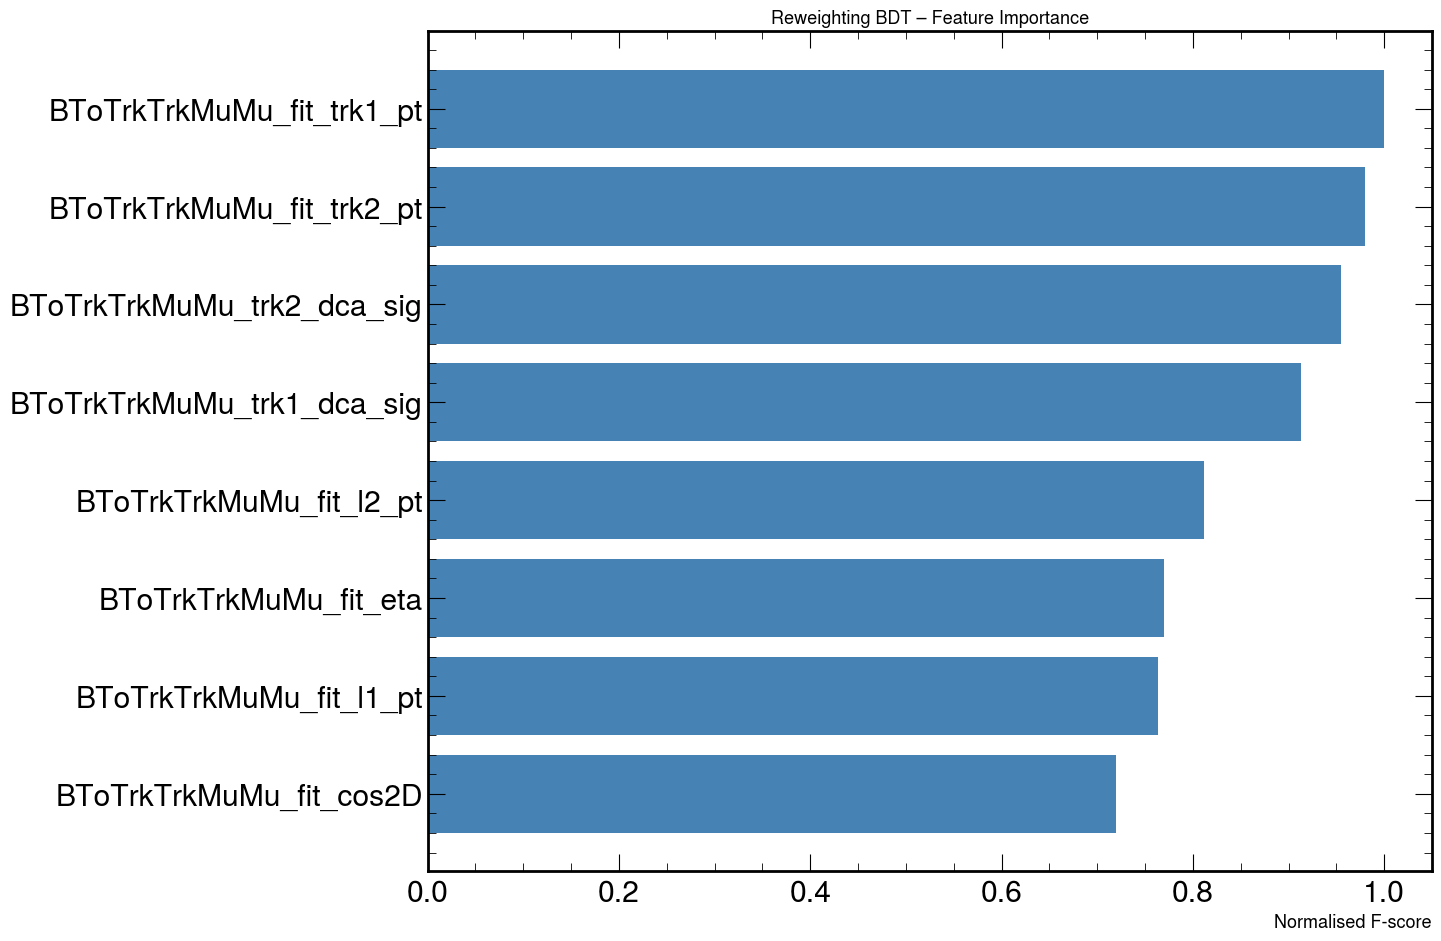

In [27]:
importances = clf.get_booster().get_fscore()
max_score   = max(importances.values())
norm_imp    = dict(sorted(
    {k: v / max_score for k, v in importances.items()}.items(),
    key=lambda x: x[1]
))

fig, ax = plt.subplots(figsize=(15, 10))
ax.barh(list(norm_imp.keys()), list(norm_imp.values()), color="steelblue")
ax.set_xlabel("Normalised F-score", fontsize=13)
ax.set_title("Reweighting BDT – Feature Importance", fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
def compute_weights(clf, df):
    proba  = clf.predict_proba(df[FEATURES])
    p_data = proba[:, 1]
    p_mc   = proba[:, 0]
    return p_data / np.clip(p_mc, 1e-6, None)

df_mc_clean["xgb_weight"] = compute_weights(clf, df_mc_clean)

print("Resumo dos pesos:")
print(df_mc_clean["xgb_weight"].describe())

Resumo dos pesos:
count    442368.000000
mean          0.979778
std           1.063619
min           0.117604
25%           0.667101
50%           0.862804
75%           1.107315
max         160.397537
Name: xgb_weight, dtype: float64


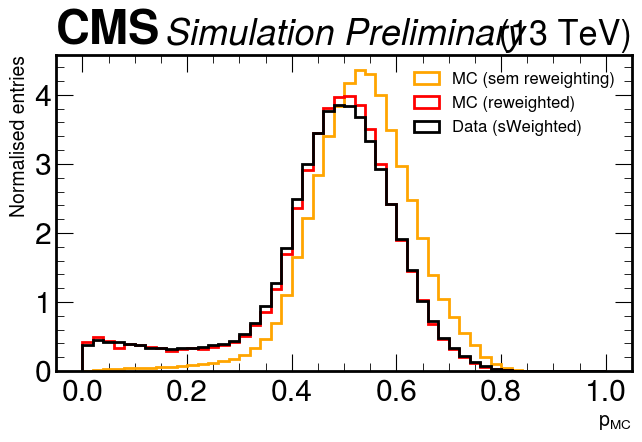

In [29]:
p_mc_of_mc_odd   = clf.predict_proba(df_mc_odd[FEATURES])[:, 0]
p_mc_of_data_odd = clf.predict_proba(df_data_odd[FEATURES])[:, 0]

rw_odd   = compute_weights(clf, df_mc_odd)
sw_odd   = df_data_odd["sweight_sig"].values
mask_pos = sw_odd > 0

fig, ax = plt.subplots(figsize=(7, 5))
bins = np.linspace(0, 1, 51)

ax.hist(p_mc_of_mc_odd,             bins=bins, density=True, histtype="step",
        lw=2, color="orange", label="MC (sem reweighting)")
ax.hist(p_mc_of_mc_odd,             bins=bins, density=True, histtype="step",
        lw=2, color="red",    label="MC (reweighted)", weights=rw_odd)
ax.hist(p_mc_of_data_odd[mask_pos], bins=bins, density=True, histtype="step",
        lw=2, color="black",  label="Data (sWeighted)", weights=sw_odd[mask_pos])

ax.set_xlabel(r"$p_{\rm MC}$", fontsize=14)
ax.set_ylabel("Normalised entries", fontsize=14)
ax.legend(fontsize=12, frameon=False)
hep.cms.label("Preliminary", ax=ax)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1771/3495880004.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


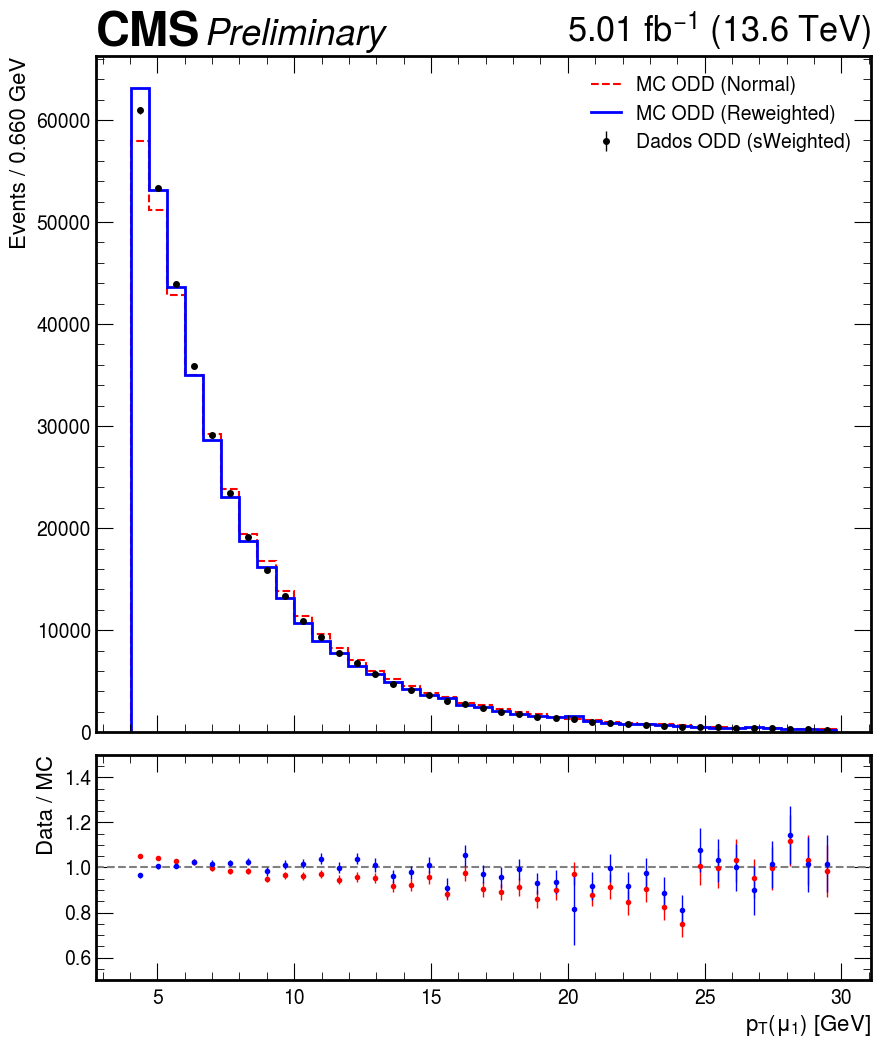

/tmp/ipykernel_1771/3495880004.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


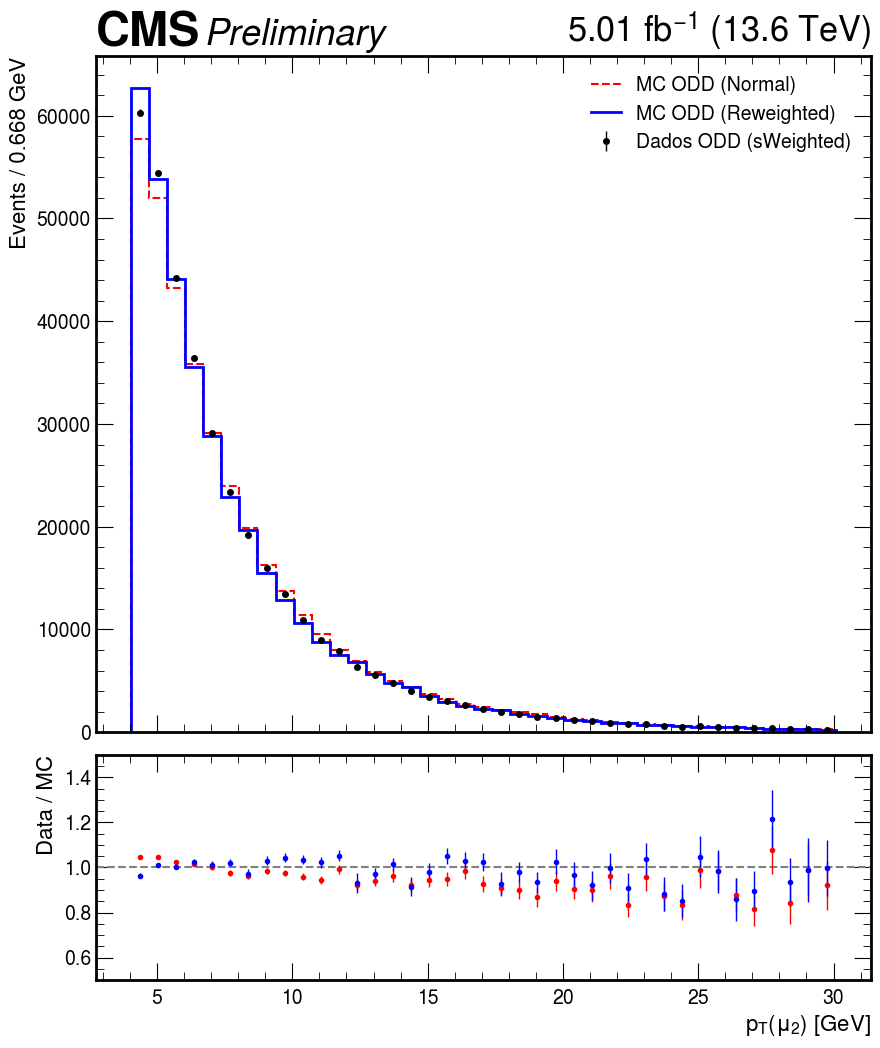

/tmp/ipykernel_1771/3495880004.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


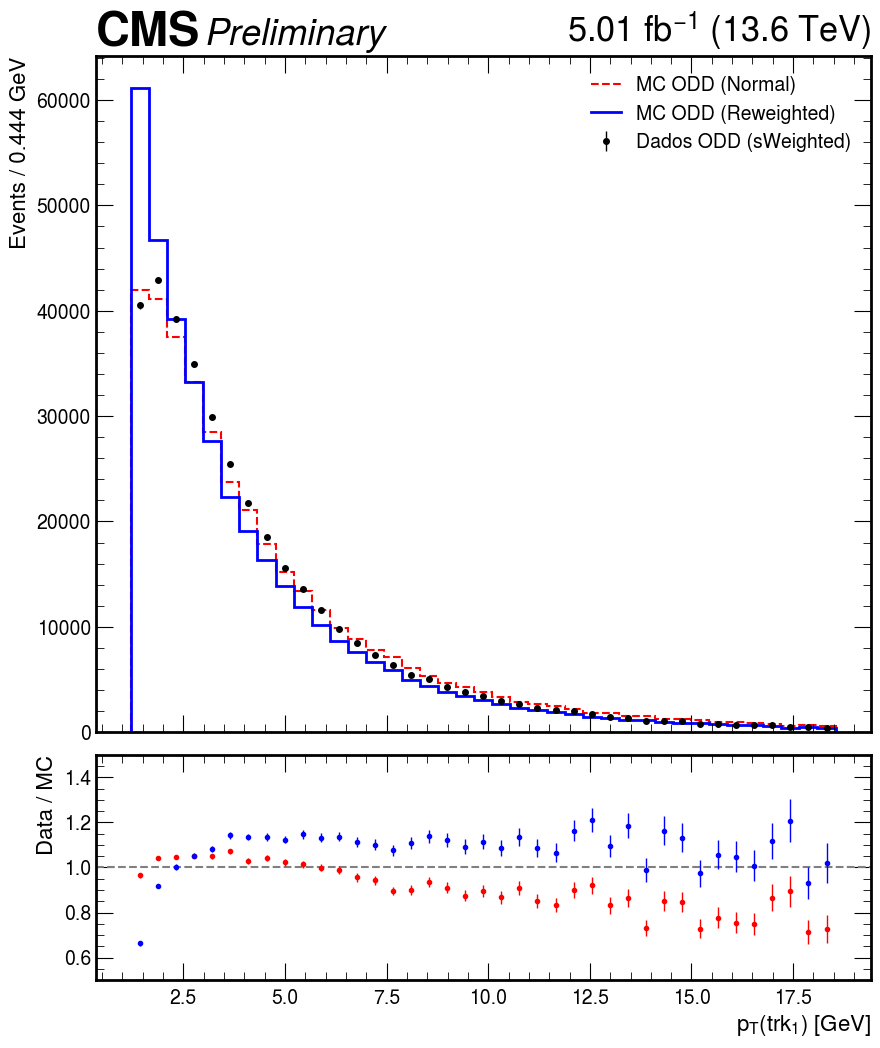

/tmp/ipykernel_1771/3495880004.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


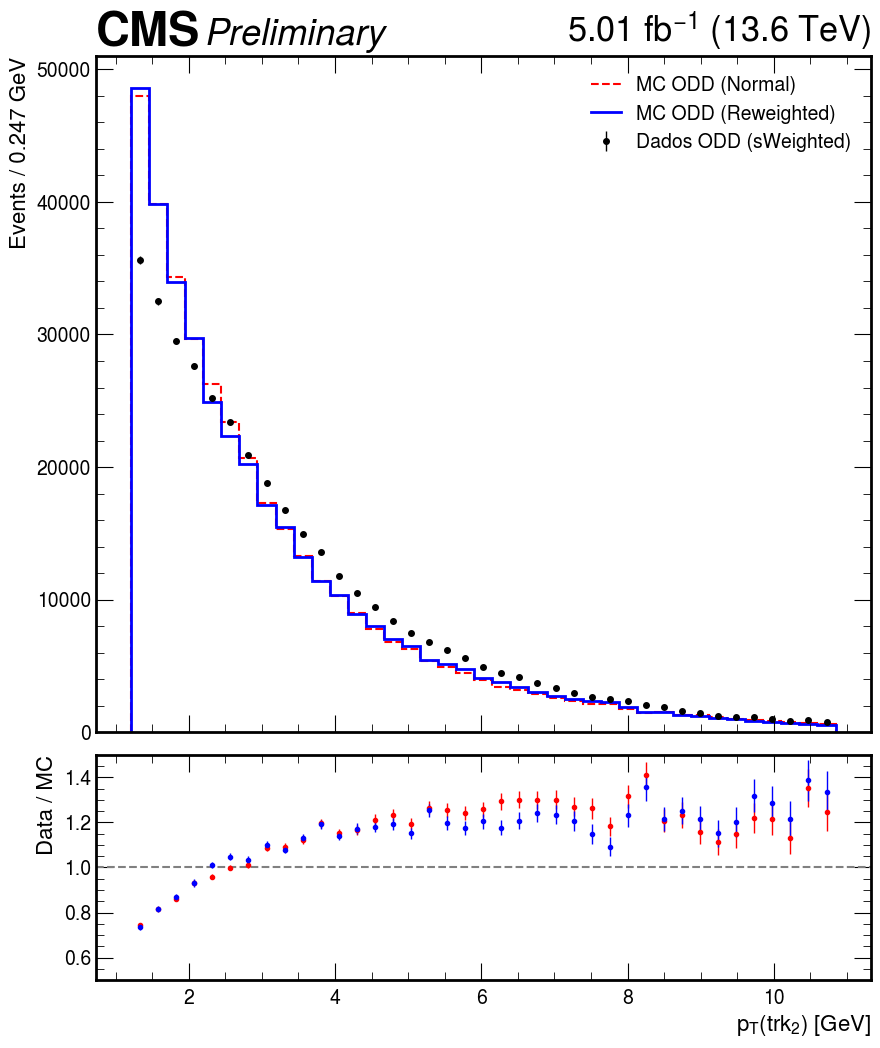

/tmp/ipykernel_1771/3495880004.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


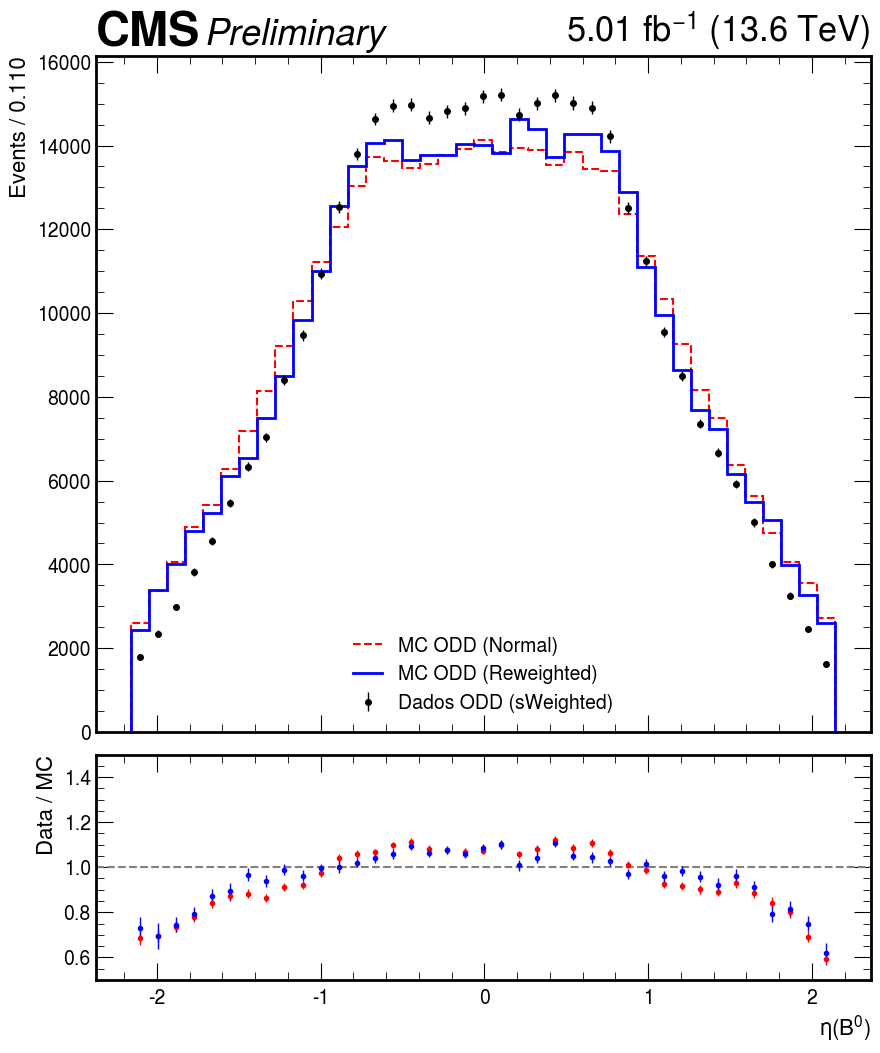

/tmp/ipykernel_1771/3495880004.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


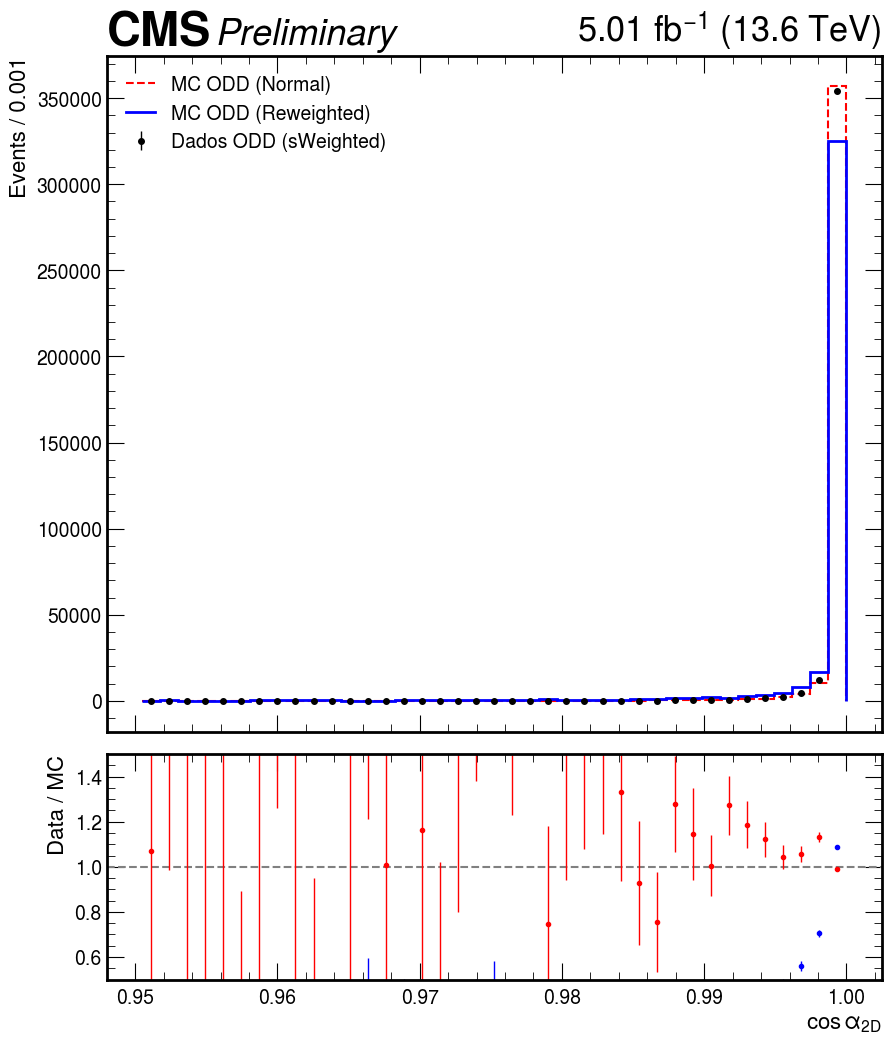

/tmp/ipykernel_1771/3495880004.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


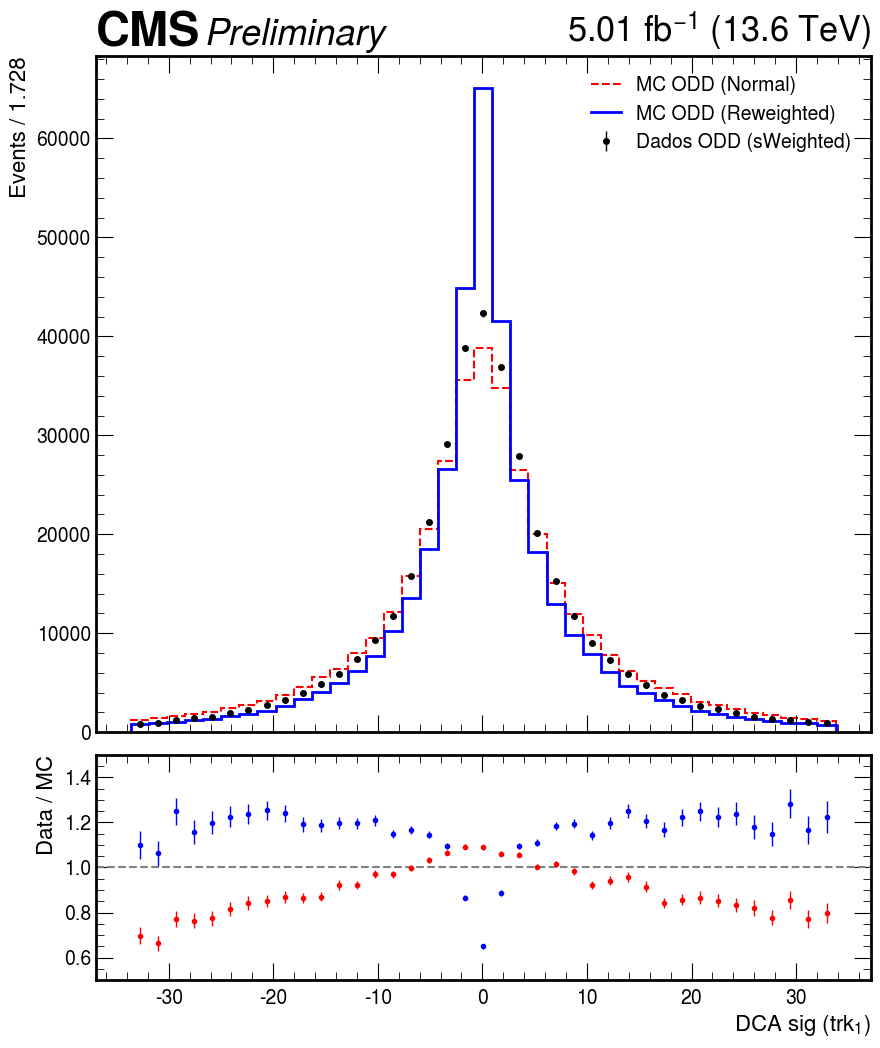

/tmp/ipykernel_1771/3495880004.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


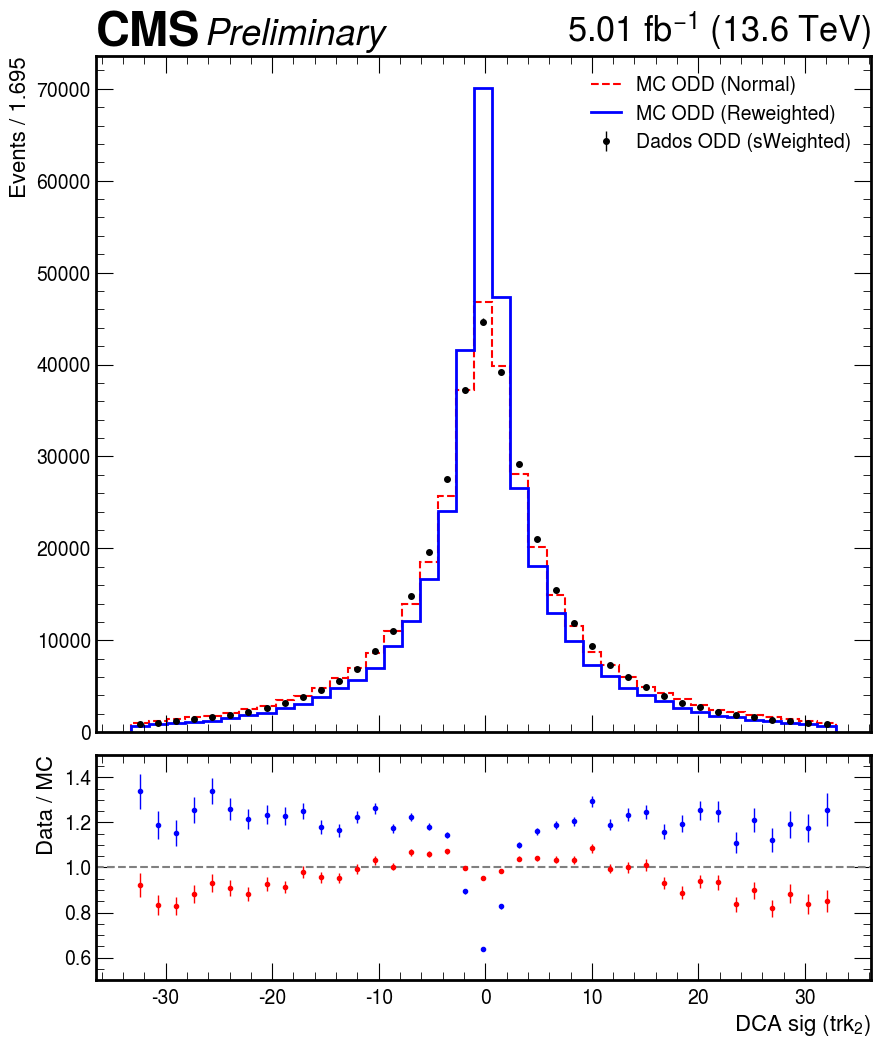

In [30]:
import os
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np

# Cria a pasta de output para o closure test caso ela não exista
os.makedirs("plots_closure_odd", exist_ok=True)
plt.style.use(hep.style.CMS)

# Calcula os pesos para a amostra ODD usando o modelo treinado
df_mc_odd["xgb_weight"] = compute_weights(clf, df_mc_odd)

for feature in FEATURES:
    # Extraindo o label formatado para o eixo X
    display_label = FEATURE_LABELS.get(feature, feature)
    
    # Extraindo os dados do dataset ODD
    data_vals = df_data_odd[feature].values
    data_weights = df_data_odd["sweight_sig"].values
    
    mc_vals = df_mc_odd[feature].values
    mc_weights_normal = np.ones_like(mc_vals)
    mc_weights_rw = df_mc_odd["xgb_weight"].values
    
    # Definindo um binning comum baseado nos dados para aquele plot
    min_val = np.percentile(data_vals, 1) # Ignora outliers extremos para o range
    max_val = np.percentile(data_vals, 99)
    bins = np.linspace(min_val, max_val, 40)
    bin_width = bins[1] - bins[0]
    
    # --- Criando a figura com 2 painéis (Plot Principal + Ratio) ---
    fig, (ax, rax) = plt.subplots(2, 1, figsize=(10, 12), 
                                  gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}, 
                                  sharex=True)
    
    # --- Cálculo dos Histogramas e Erros ---
    h_dat, _ = np.histogram(data_vals, bins=bins, weights=data_weights)
    h_dat_err = np.sqrt(np.histogram(data_vals, bins=bins, weights=data_weights**2)[0])
    
    h_raw_v, _ = np.histogram(mc_vals, bins=bins, weights=mc_weights_normal)
    h_raw_err = np.sqrt(h_raw_v)
    
    h_cor, _ = np.histogram(mc_vals, bins=bins, weights=mc_weights_rw)
    h_cor_err = np.sqrt(np.histogram(mc_vals, bins=bins, weights=mc_weights_rw**2)[0])

    # Normalização (Escalando o MC para ter a mesma área/yield dos Dados)
    s_raw = h_dat.sum() / h_raw_v.sum() if h_raw_v.sum() > 0 else 1
    s_cor = h_dat.sum() / h_cor.sum() if h_cor.sum() > 0 else 1
    
    # --- Plot Superior ---
    # Dados como pontos pretos com barras de erro
    hep.histplot(h_dat, bins=bins, yerr=h_dat_err, label='Dados ODD (sWeighted)', 
                 ax=ax, histtype='errorbar', color='black', marker='o', markersize=4)
    
    # MC Original e Corrigido escalados
    hep.histplot(h_raw_v * s_raw, bins=bins, label='MC ODD (Normal)', 
                 ax=ax, color='red', linestyle='--')
    hep.histplot(h_cor * s_cor, bins=bins, label='MC ODD (Reweighted)', 
                 ax=ax, color='blue', lw=2)
    
    # Descomente a linha abaixo se quiser o eixo Y em log scale
    # ax.set_yscale('log')
    
    # Lógica do Eixo Y Dinâmico
    if "GeV" in display_label:
        y_label = f"Events / {bin_width:.3f} GeV"
    else:
        y_label = f"Events / {bin_width:.3f}"
        
    ax.set_ylabel(y_label, fontsize=16)
    ax.legend(fontsize=14)
    hep.cms.label("Preliminary", data=True, lumi=5.01, com=13.6, loc=0, ax=ax)
    
    # --- Ratio Plot Inferior ---
    with np.errstate(divide='ignore', invalid='ignore'):
        r_raw = h_dat / (h_raw_v * s_raw)
        # Usando o np.abs() que resolve o problema do erro negativo
        e_raw = np.abs(r_raw) * np.sqrt((h_dat_err/h_dat)**2 + (h_raw_err/h_raw_v)**2)
        
        r_cor = h_dat / (h_cor * s_cor)
        e_cor = np.abs(r_cor) * np.sqrt((h_dat_err/h_dat)**2 + (h_cor_err/h_cor)**2)
        
        for e in [e_raw, e_cor]: e[~np.isfinite(e)] = 0

    rax.axhline(1, color='gray', linestyle='--')
    hep.histplot(r_raw, bins=bins, yerr=e_raw, ax=rax, color='red', 
                 histtype='errorbar', marker='o', markersize=3)
    hep.histplot(r_cor, bins=bins, yerr=e_cor, ax=rax, color='blue', 
                 histtype='errorbar', marker='o', markersize=3)
    
    rax.set_ylim(0.5, 1.5)
    rax.set_ylabel("Data / MC", fontsize=16)
    rax.set_xlabel(display_label, fontsize=16) 
    
    ax.tick_params(axis='both', which='major', labelsize=14)
    rax.tick_params(axis='both', which='major', labelsize=14)
    
    plt.tight_layout()
    plt.savefig(f"plots_closure_odd/Comp_{feature}_ODD_closure.png", bbox_inches='tight')
    plt.show()

In [31]:
model_filename = "xgb_reweighting_model.joblib"
joblib.dump(clf, model_filename)

['xgb_reweighting_model.joblib']